<a href="https://colab.research.google.com/github/reijohnson/DATA201-Labs/blob/main/Lab03_week3_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Logistic Regression

A credit card default means you have failed to make your required minimum payments for an extended period, usually around 180 days (six months).

In this lab, we will use customer information to build a logistic regression model that predicts whether a customer will default on their credit card.

Our dataset includes variables such as:

- credit card balance
- income
- student status
- whether the customer actually defaulted

Our goal is not just to produce a Yes/No prediction. We will examine the full classification process:

$$ \text{Customer Features} \rightarrow \text{Logistic Regression} \rightarrow \text{Predicted Probability} \rightarrow \text{Threshold} \rightarrow \text{Predicted Class} $$

We will then investigate how changing the probability threshold changes the model's classifications and examine the logistic regression decision boundary.

Part 1 - Load and inspect the data

In [3]:
#mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#After you authorize access, load the dataset from your Datasets folder. Make sure the file path is correct
import pandas as pd

file_path = "/content/drive/MyDrive/MC/DATA201/Datasets/Default.csv"

Default = pd.read_csv(file_path)

Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


Inspect the dataset!

In [5]:
Default.shape

(10000, 4)

In [6]:
Default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [7]:
Default["default"].value_counts()

,count
default,
No,9667
Yes,333


In [8]:
Default[["balance", "income"]].describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


**Questions**

Q1. What does each row represent?

A1. Each row represents a credit card case, or a person's specific credit card.

Q2. What is the target variable?

A2. The target variable is 'default'.

Q3. Which variables could be used as predictors?

A3. Variables 'income' and 'balance' can be used as predictors.

Q4. Is the target balanced across the two classes?

A4. No, there are far less defaults than non-defaults.

Logistic regression does not require scaling, but scaling is recommended when predictors are on very different scales.

### Part 2 - Visualize Balance and Default

We will begin with credit card balance as our only predictor.

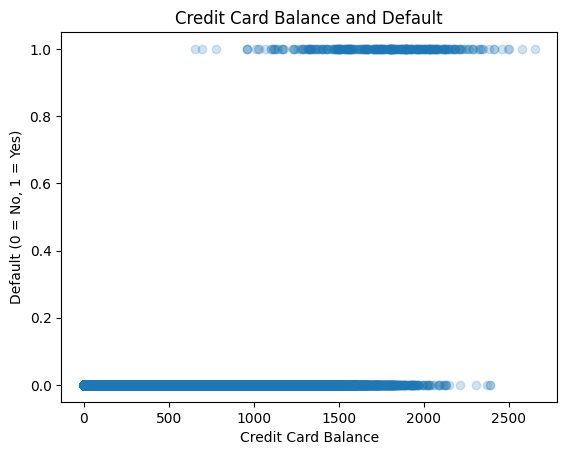

In [9]:
import matplotlib.pyplot as plt

plt.scatter(
    Default["balance"],
    Default["default"].map({"No": 0, "Yes": 1}),
    alpha=0.2
)

plt.xlabel("Credit Card Balance")
plt.ylabel("Default (0 = No, 1 = Yes)")
plt.title("Credit Card Balance and Default")
plt.show()

Questions

Q5. What pattern do you notice between credit card balance and default?

A5. Higher balances have far higher defaults than low balances.

Q6. Why would ordinary linear regression not be ideal for predicting an outcome that can only be Yes or No?

A6. Linear regression operates on a slope function which would have trouble finding where between the 0 and 1 to sit, and even further.

### Part 3 - Prepare the Data


In [10]:
#Convert the target variable into numeric form
Default["default_num"] = Default["default"].map({
    "No": 0,
    "Yes": 1
})

In [11]:
# define features and target
X = Default[["balance"]]
y = Default["default_num"]

In [12]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25, #this is the default %, you can remove this line if you want to
    random_state=42,
    stratify=y
)

`stratify=y` means the train/test split will preserve roughly the same proportion of each class as the original target y.

For example, if the full dataset is about:
- 97% No Default
- 3% Default

then using `stratify=y` tries to keep both the training set and test set at about that same 97% / 3% split.

That is especially useful here because default is quite imbalanced. Without stratification, the test set could accidentally end up with too few default cases.

Questions

Q7. Which variable is our predictor?

A7. The 'balance' variable is used as the predictor.

Q8. Which variable is our target?

A8. The 'default' variable is used as the target.

Q9. Why do we separate the data into training and test sets?

A9. Training and test data are used to train the model's numbers, and then see if they match up to unseen real-world data before actual applications.

The goal is to train the model using one portion of the data and then evaluate how well it performs on new, unseen observations.

### Part 4 - Fit a Logistic Regression Model

We will now fit logistic regression using only balance.

In [13]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

logreg.fit(X_train, y_train)

LogisticRegression()

The fitted model has the form:

$$ z=\beta_0+\beta_1X $$

where:

- $\beta_0$ is the intercept
- $\beta_1$ is the coefficient for balance
- X is the customer's credit card balance

Let's inspect the values learned by the model.

In [14]:
#Inspect the values learned by the model
beta_0 = logreg.intercept_[0]
beta_1 = logreg.coef_[0][0]

print("Intercept:", beta_0)
print("Balance coefficient:", beta_1)

Intercept: -10.806505437069939
Balance coefficient: 0.005613164019786544


Questions

Q10. Is the coefficient for balance positive or negative?

A10. Negative (>1)

Q11. Based on the sign of the coefficient, what happens to \(z\) as balance increases?

A11. A will increase.

Q12. What should happen to the estimated probability of default as \(z\) increases?

A12. Probability of a default will increase as well. Higher balance leads to higher probability of default.

In this fitted model, higher credit card balances are associated with a higher predicted probability of default.

Note, the coefficient seems small because balance is measured in single dollars; over realistic changes in balance, its effect on \(z\) can be substantial.

### Part 5 - Calculate \(z\) and Probability for One Customer

Select one customer from the test set.

In [15]:
customer = X_test.iloc[[0]]

customer

,balance
2605,76.476089


Now calculate the linear score manually: z=β0 +β1X

In [16]:
balance = customer["balance"].iloc[0]

z = beta_0 + beta_1 * balance

print("z =", z)

z = -10.377232606170354


Remember:

\(z\) is the linear score. It is not yet a probability.
Now apply the logistic, or sigmoid, function:

$$p(X) = \frac{e^x}{1 + e^x}$$


In [17]:
import numpy as np

p_manual = np.exp(z) / (1 + np.exp(z))

print("Probability of Default:", p_manual)

Probability of Default: 3.1132329685966765e-05


In [18]:
# Now compare your calculation with scikit-learn
logreg.predict_proba(customer)

array([[9.99968868e-01, 3.11323297e-05]])

The output contains two probabilities: P(No Default) and P(Default)

The probabilities sum to 1, and predict_proba() gives the model's estimated probability for each class.

Questions

Q13. Does your manually calculated probability match the second value returned by predict_proba()?

A13. Yes.

Q14. Why are there two probabilities?

A14. There is a probability of non-default and a probability of default, not just probability of default.

Q15. Is the probability itself the final class prediction?

A15. No, a threshold is required.

### Part 6 - Probability vs. Prediction

Let's calculate the probability of default for every customer in the test set.

In [19]:
prob_default = logreg.predict_proba(X_test)[:, 1]
prob_default

#[:,1] means all rows (:) and the second column (1) (the second column represent the Default = Yes probability)

array([3.11323297e-05, 1.85245551e-02, 4.74884085e-04, ...,
       2.81876304e-02, 6.61667900e-05, 2.00262109e-04])

In [20]:
#obtain the model's class predictions
pred_50 = logreg.predict(X_test)

In [21]:
#Create a table to compare the results
results = X_test.copy()

results["Actual"] = y_test.values
results["P(Default)"] = prob_default
results["Prediction_0.50"] = pred_50

results.head(15)

,balance,Actual,P(Default),Prediction_0.50
2605,76.476089,0,0.000031,0
8431,1217.948660,0,0.018525,0
7149,561.989745,0,0.000475,0
1890,806.996111,0,0.001876,0
8848,1018.366790,0,0.006119,0
5010,0.000000,0,0.000020,0
1636,386.265071,0,0.000177,0
1103,1275.824225,0,0.025454,0
4266,1464.028962,0,0.069871,0
3323,1922.829046,1,0.496662,0


The standard binary classification rule is:

$$ p(X)\ge0.50 \Rightarrow \text{Class 1} $$
$$ p(X)<0.50⇒Class 0 $$

Questions

Q16. Find a customer with a predicted probability close to 0.50.

A16. Customer 3323 has 0.496662 probability of default.

Q17. What class does a probability of 0.49 receive?

A17. Non-default.

Q18. What class does a probability of 0.51 receive?

A18. Default.

Q19. Are 0.49 and 0.51 very different probabilities, even though they produce different class labels?

A19. No, they are very very close together, only a 2% difference.

### Part 7 - Change the Classification Threshold

The logistic regression model produces the probability.

The threshold determines how we convert that probability into a class.



In [22]:
#Now lower the threshold to 0.30.

results["Prediction_0.30"] = (
    results["P(Default)"] >= 0.30
).astype(int)

results.head()

,balance,Actual,P(Default),Prediction_0.50,Prediction_0.30
2605,76.476089,0,0.000031,0,0
8431,1217.948660,0,0.018525,0,0
7149,561.989745,0,0.000475,0,0
1890,806.996111,0,0.001876,0,0
8848,1018.366790,0,0.006119,0,0


In [23]:
#Find the observations whose predicted class changed

changed = results[
    results["Prediction_0.50"] != results["Prediction_0.30"]
]

changed.head(15)

,balance,Actual,P(Default),Prediction_0.50,Prediction_0.30
3323,1922.829046,1,0.496662,0,1
314,1809.926564,0,0.343645,0,1
9796,1867.308569,1,0.419459,0,1
8552,1814.105649,0,0.348956,0,1
6854,1923.381941,0,0.497438,0,1
7661,1809.409864,1,0.342992,0,1
5482,1850.888247,0,0.397195,0,1
4782,1839.322208,0,0.381759,0,1
5488,1814.168195,0,0.349035,0,1
6541,1797.767019,1,0.328419,0,1


changing the classification cutoff changes which customers are classified as defaulting

Questions

Q20. Which customers changed classification?

A20. All customers with a probability of default over 0.3 changed classification.

Q21. Did their predicted probabilities change?

A21. No, threshold does not change the regression itself.

Q22. Did we retrain the logistic regression model?

A22. No.

Q23. What changed?

A23. The decision process itself and therefore the decision.

The important conclusion is:

Changing the threshold changes the decision rule, not the fitted model.

### Part 8 - Compare the Types of Errors

Let's examine the predictions using a confusion matrix.

In [24]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    results["Actual"],
    results["Prediction_0.50"])

array([[2404,   13],
       [  56,   27]])

For binary classification, the matrix represents:
|                |   Predicted No |  Predicted Yes |
| -------------- | -------------: | -------------: |
| **Actual No**  |  True Negative | False Positive |
| **Actual Yes** | False Negative |  True Positive |


In [25]:
#Now compare with the 0.30 threshold:

confusion_matrix(
    results["Actual"],
    results["Prediction_0.30"]
)

array([[2367,   50],
       [  43,   40]])

Questions

Q24. What happens to the number of false negatives when the threshold decreases?

A24. False negatives somewhat decrease.

Q25. What happens to the number of false positives?

A25. False positives increase.

Q26. Does lowering the threshold automatically make the model better?

A26. No, it introduces potential for improvement at the cost of false positives/false negatives.

Q27. Why might a lower threshold be useful in some applications but undesirable in other

A27. More straightforward data will generally benefit from threshold changes, however more convoluted data may introduce false positives and false negatives.

### Part 9 - Add Income as a Second Predictor

Now we will expand the model.

Instead of using only balance, use balance and income

In [26]:
X2 = Default[["balance", "income"]]
y = Default["default_num"]

Recall what we observed earlier:

- balance is generally measured in the hundreds or low thousands;
- income is generally measured in the tens of thousands.

Because the two predictors are on very different scales, we will now standardize them before fitting logistic regression.

#### First split the data.

In [27]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

### Part 10 - Scale the Predictors

We learned in Week 2 that we should split before scaling.

Fit the scaler only to the training data.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

### Part 11 - Fit the Two-Predictor Logistic Regression Model

In [29]:
logreg2 = LogisticRegression()

logreg2.fit(X2_train_scaled, y2_train)

LogisticRegression()

In [30]:
#Look at the fitted coefficients

print("Intercept:", logreg2.intercept_)
print("Coefficients:", logreg2.coef_)

Intercept: [-6.07550723]
Coefficients: [[2.69776916 0.22470348]]


Scaling changes the units of the predictor, so the coefficient changes too.

- 0.0056 = effect of increasing balance by $1 in the unscaled one-predictor model
- 2.6978 = effect of increasing balance by 1 standard deviation in the scaled two-predictor model

In [31]:
#display them

coefficients = pd.DataFrame({
    "Feature": ["balance", "income"],
    "Coefficient": logreg2.coef_[0]
})

coefficients

,Feature,Coefficient
0,balance,2.697769
1,income,0.224703


Questions

Q29. Which coefficient is positive?

A29. Balance.

Q30. Which coefficient is negative?

A30. Income.

Q31. Based on the signs of the coefficients, how is each predictor related to the model's default score?

A31. As balance increases, probability of default increases, as income decreases, probability of default increases and vice versa.

### Part 12 - The Decision Boundary

With two predictors, logistic regression calculates:

$$ z=\beta_0+\beta_1X_1+\beta_2X_2 $$

At a threshold of 0.50:

$$ p(X)=0.50 $$

which corresponds to:

$$ z=0 $$

Therefore, the decision boundary is:

$$ \beta_0+\beta_1X_1+\beta_2X_2=0 $$

The decision boundary separates the region classified as Class 0 from the region classified as Class 1.

Logistic regression's two-dimensional decision boundary as a straight line separating the two predicted regions. Because we scaled our predictors, it is easiest to visualize the boundary in the scaled feature space.

In [32]:
# Extract the fitted logistic regression parameters
beta_0 = logreg2.intercept_[0]
beta_balance = logreg2.coef_[0][0]  # scaled balance
beta_income = logreg2.coef_[0][1]    # scaled income

In [33]:
# Create 200 evenly spaced balance values across the training-data range
# These values will be used to draw the decision boundary line
x_vals = np.linspace(
    X2_train_scaled[:, 0].min(),
    X2_train_scaled[:, 0].max(),
    200
)

Solve the decision-boundary equation for scaled income:

$$ X_2= -\frac{\beta_0+\beta_1X_1}{\beta_2} $$

In [34]:
y_vals = -(
    beta_0 + beta_balance * x_vals
) / beta_income

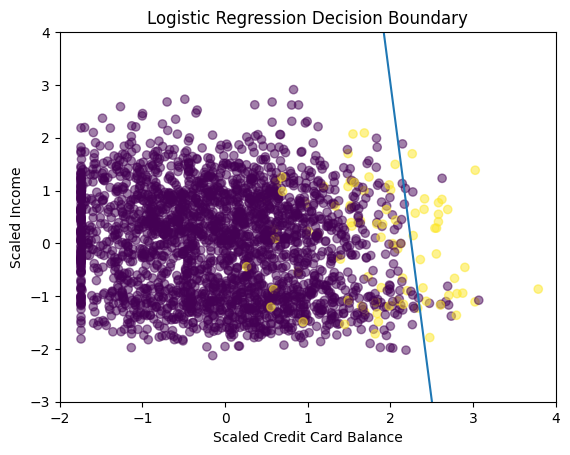

In [35]:
#Plot the test observations and the decision boundary.

plt.scatter(
    X2_test_scaled[:, 0],
    X2_test_scaled[:, 1],
    c=y2_test,
    alpha=0.5
)

plt.plot(x_vals, y_vals)

plt.xlabel("Scaled Credit Card Balance")
plt.ylabel("Scaled Income")
plt.title("Logistic Regression Decision Boundary")

plt.xlim(-2, 4)
plt.ylim(-3, 4)

plt.show()

- The purple points are mostly non-default customers.
- The yellow points are default customers.
- The blue line is the \(p=0.50\) decision boundary.
- Customers to one side of the line are classified as one class, and customers to the other side are classified as the other class.

The boundary is almost vertical. That means the model is relying much more on credit card balance than on income to separate the classes. Income changes the boundary only slightly.

In [36]:
print("Intercept:", beta_0)
print("Balance coefficient:", beta_balance)
print("Income coefficient:", beta_income)

Intercept: -6.0755072345282235
Balance coefficient: 2.6977691568867255
Income coefficient: 0.2247034838059329
